# Daniyal Khan || 221A061 || 19

Model Performance:
------------------------------
Single Decision Tree: 0.9474
Random Forest (Bagging): 0.9649
AdaBoost (Boosting): 0.9737


/tmp/ipykernel_4865/2717553160.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracy_scores, palette="viridis", ax=axes[0])


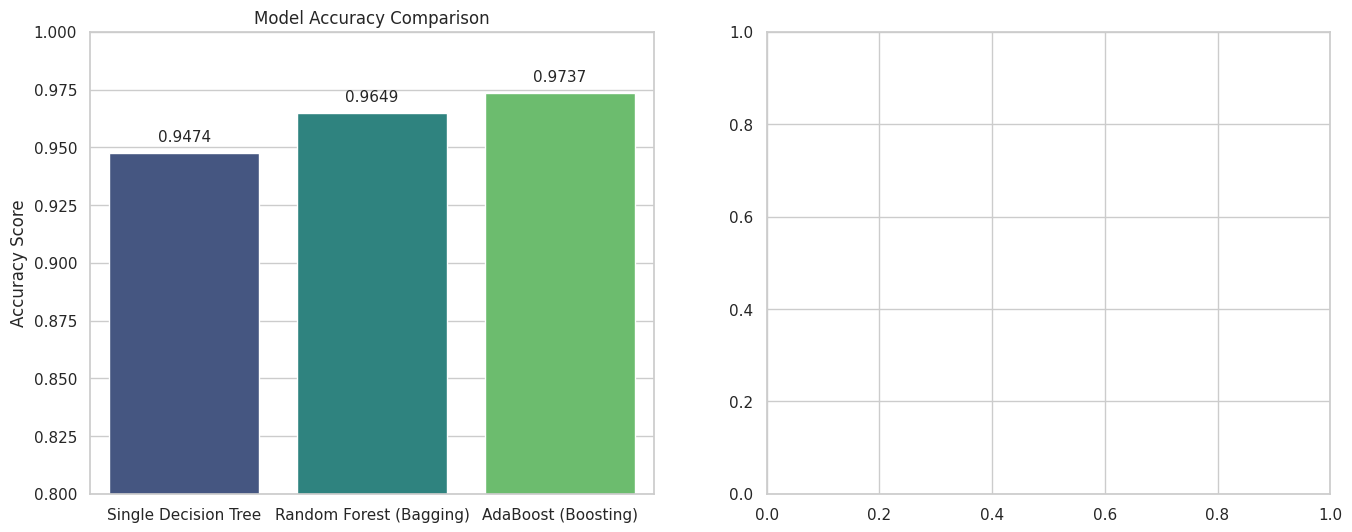

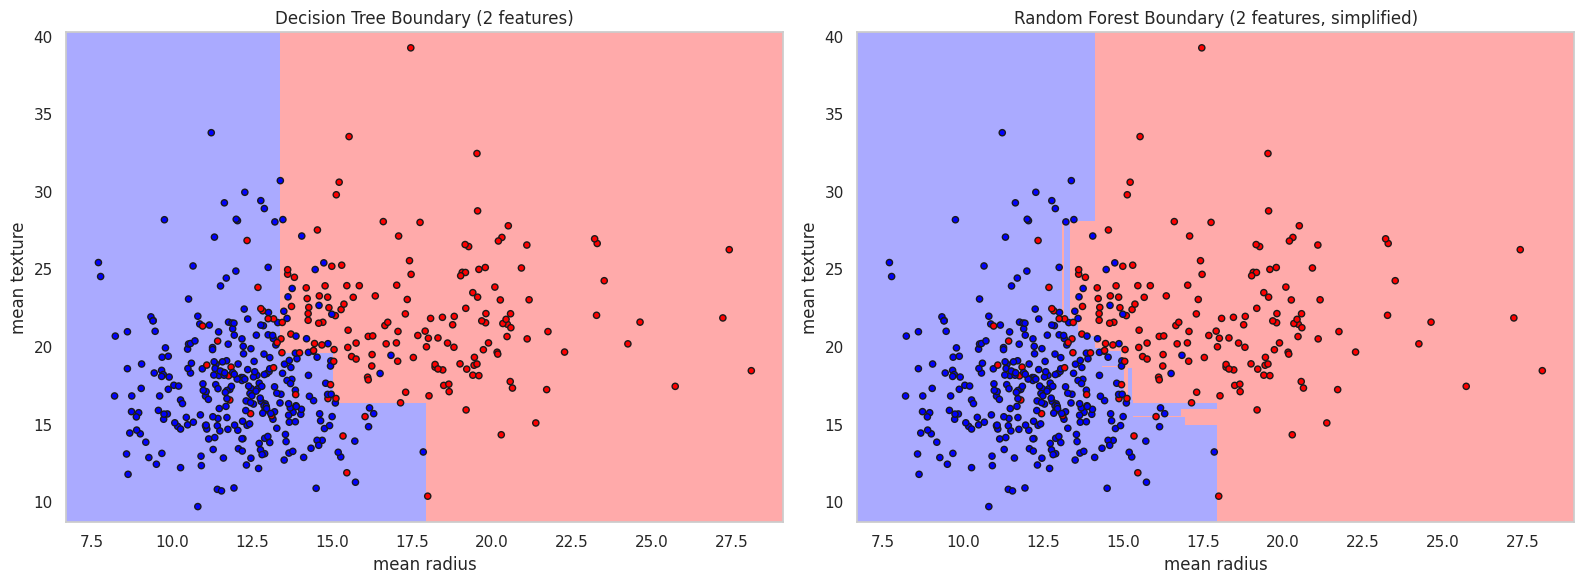

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# --- 1. Load and prepare the data ---
data = load_breast_cancer()
X, y = data.data, data.target
# Feature names for the DataFrame
feature_names = data.feature_names
target_names = data.target_names

# Create a DataFrame for easier handling
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. Initialize and Train the models ---
# A single decision tree (Baseline)
tree = DecisionTreeClassifier(random_state=42)

# Bagging: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Boosting: AdaBoost
boost = AdaBoostClassifier(n_estimators=100, random_state=42)

models = {
    "Single Decision Tree": tree,
    "Random Forest (Bagging)": rf,
    "AdaBoost (Boosting)": boost
}

# Collect accuracy scores for visualization
accuracy_scores = []
model_names = []

print("Model Performance:")
print("-" * 30)

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    accuracy_scores.append(accuracy)
    model_names.append(name)
    print(f"{name}: {accuracy:.4f}")

# --- 3. Visualization ---

# Set a stylish seaborn theme
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Accuracy Comparison (Bar Chart)
# This visualization shows how much better the ensemble models perform.
sns.barplot(x=model_names, y=accuracy_scores, palette="viridis", ax=axes[0])
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylabel("Accuracy Score")
axes[0].set_ylim(0.8, 1.0) # Zoom in to see the differences clearly
for i, v in enumerate(accuracy_scores):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=11)

# Subplot 2: Decision Boundaries (Decision Tree vs. Random Forest)
# We'll visualize this on a subset of the data (the first two features) to make it easy.
# NOTE: This part is highly simplified to fit in a 2D graph.
from matplotlib.colors import ListedColormap
import numpy as np

# We only take the first two features for 2D visualization
X_visual = X_train[:, :2]
tree_2d = DecisionTreeClassifier(max_depth=3).fit(X_visual, y_train)
rf_2d = RandomForestClassifier(n_estimators=10, max_depth=3).fit(X_visual, y_train)

def plot_decision_boundary(clf, X, y, ax, title):
    # Step size of the mesh
    h = .02
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict for each point in the mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundaries
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    ax.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Plot the training points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#FF0000', '#0000FF']), edgecolor='k', s=20)

    ax.set_title(title)
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    # Legend manually defined
    # ax.legend(handles=scatter.legend_elements()[0], labels=list(target_names))

# Create separate plots for boundaries to keep it clear
fig_boundary, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plot_decision_boundary(tree_2d, X_visual, y_train, ax1, "Decision Tree Boundary (2 features)")
plot_decision_boundary(rf_2d, X_visual, y_train, ax2, "Random Forest Boundary (2 features, simplified)")

# Display the plots
plt.tight_layout()
plt.show()